# 제조업 생산 설비 에너지 비효율 분석 및 이상 탐지

> AI 기술을 활용한 지속가능한 에너지·환경 솔루션 아이디어 공모전 — 예선 제출물

**분석 기간:** 2024-12-01 ~ 2025-04-29 | **설비 수:** 13개 | **데이터:** 약 3,370만 건

---

## 분석 흐름
1. 데이터 로드 및 전처리
2. 시간대별·설비별 EDA
3. 비효율 구간 정의 (IQR 기반)
4. Isolation Forest 이상 탐지 모델
5. 에너지·탄소 배출 분석
6. 시각화

## 1. 라이브러리 로드 및 데이터 준비

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 120

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/contest/rtu_data_extracted/rtu_data_full.csv")

Mounted at /content/drive


## 2. 데이터 전처리

`timestamp` (epoch ms)와 `localtime` (YYYYMMDDHHMMSS) 두 시간 컬럼 간 8시간 차이가 존재한다.
이는 미국 DST(일광절약시간) 차이로 판명되었으며, **`localtime` 기준**으로 분석을 진행한다.

In [3]:
# localtime 파싱
df['localtime_parsed'] = pd.to_datetime(df['localtime'].astype(str), format='%Y%m%d%H%M%S')

# 불필요한 컬럼 제거
df = df.drop(columns=['timestamp', 'localtime'])
df = df.rename(columns={'localtime_parsed': 'datetime'})

print(f"데이터 형태: {df.shape}")
print(f"기간: {df['datetime'].min()} ~ {df['datetime'].max()}")
print(f"\n결측치:")
print(df.isnull().sum())
print(f"\n설비 수: {df['module(equipment)'].nunique()}개")
print(df['module(equipment)'].value_counts())

데이터 형태: (33696013, 18)
기간: 2024-12-01 00:00:00 ~ 2025-04-30 00:00:00

결측치:
module(equipment)       0
operation               0
voltageR                0
voltageS                0
voltageT                0
voltageRS               0
voltageST               0
voltageTR               0
currentR                0
currentS                0
currentT                0
activePower             0
powerFactorR            0
powerFactorS            0
powerFactorT            0
reactivePowerLagging    0
accumActiveEnergy       0
datetime                0
dtype: int64

설비 수: 13개
module(equipment)
1(PM-3)       2592001
2(L-1전등)      2592001
3(분쇄기(2))     2592001
4(분쇄기(1))     2592001
5(좌측분전반)      2592001
11(우측분전반1)    2592001
12(4호기)       2592001
13(3호기)       2592001
14(2호기)       2592001
15(예비건조기)     2592001
16(호이스트)      2592001
17(6호기)       2592001
18(우측분전반2)    2592001
Name: count, dtype: int64


## 3. EDA — 설비 운영 패턴 분석

### 3-1. 시간대별 전력 소비 패턴

데이터센터 환경 특성상 **24시간 상시 가동(Constant Load)** 패턴을 보인다.
피크 시간대가 존재하지 않으므로, 전통적인 피크 절감 전략보다 **역률 관리 및 이상 탐지**가 효과적이다.

In [4]:
# 시간대별 평균 activePower
df['hour'] = df['datetime'].dt.hour

hourly_by_equip = df.groupby(['module(equipment)', 'hour'])['activePower'].mean().unstack()
hourly_range = hourly_by_equip.max(axis=1) - hourly_by_equip.min(axis=1)

print("설비별 시간대 최대-최소 차이 (W):")
print(hourly_range.sort_values(ascending=False))
print(f"\n전 설비 평균 activePower: {df['activePower'].mean():.0f}W (std: {df['activePower'].std():.0f}W)")
print("→ 시간대별 변동 1% 미만 — 피크 시간대 없음")

설비별 시간대 최대-최소 차이 (W):
module(equipment)
5(좌측분전반)      13.007037
11(우측분전반1)    11.061454
14(2호기)       10.733461
15(예비건조기)      9.820822
18(우측분전반2)     9.773602
2(L-1전등)       9.010711
17(6호기)        8.778510
4(분쇄기(1))      8.628090
12(4호기)        8.384606
13(3호기)        8.315522
1(PM-3)        8.122167
16(호이스트)       7.168920
3(분쇄기(2))      6.581389
dtype: float64

전 설비 평균 activePower: 3010W (std: 717W)
→ 시간대별 변동 1% 미만 — 피크 시간대 없음


### 3-2. 역률(Power Factor) 분포

3상 역률 평균(`pf_avg`)을 산출하여 설비별 분포를 확인한다.

In [5]:
df['pf_avg'] = (df['powerFactorR'] + df['powerFactorS'] + df['powerFactorT']) / 3

stats = df.groupby('module(equipment)')['pf_avg'].agg(['mean', 'std'])
print("설비별 평균 역률:")
print(stats.round(2))
print(f"\n전체 평균 역률: {df['pf_avg'].mean():.1f}% (std: {df['pf_avg'].std():.1f})")

설비별 평균 역률:
                    mean   std
module(equipment)             
1(PM-3)            92.50  2.50
11(우측분전반1)         92.50  2.50
12(4호기)            92.50  2.50
13(3호기)            92.50  2.50
14(2호기)            92.50  2.50
15(예비건조기)          92.25  3.54
16(호이스트)           92.50  2.50
17(6호기)            92.35  2.91
18(우측분전반2)         92.50  2.50
2(L-1전등)           92.50  2.50
3(분쇄기(2))          92.50  2.50
4(분쇄기(1))          92.50  2.50
5(좌측분전반)           92.50  2.50

전체 평균 역률: 92.5% (std: 2.6)


## 4. 비효율 구간 정의 — IQR 기반 임계값

역률이 **92~93% 구간에 강하게 집중**된 왼쪽 꼬리 분포를 보이므로,
평균 기반 임계값 대신 **IQR 방식**을 채택한다.
극단값에 강건하며, 전력 품질 관리에서 보편적으로 활용되는 방법론이다.

In [6]:
Q1 = df['pf_avg'].quantile(0.25)
Q3 = df['pf_avg'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"하한 임계값 (Q1 - 1.5×IQR): {lower_bound:.2f}%")

inefficient = df[df['pf_avg'] < lower_bound]
print(f"\n비효율 구간: {len(inefficient):,}건 ({len(inefficient)/len(df)*100:.2f}%)")
print("\n설비별 역률 급락 이벤트:")
print(inefficient.groupby('module(equipment)').size().sort_values(ascending=False))

Q1: 90.73
Q3: 94.26
IQR: 3.54
하한 임계값 (Q1 - 1.5×IQR): 85.42%

비효율 구간: 55,336건 (0.16%)

설비별 역률 급락 이벤트:
module(equipment)
15(예비건조기)     26501
17(6호기)       25951
13(3호기)         294
14(2호기)         276
4(분쇄기(1))       273
5(좌측분전반)        271
18(우측분전반2)      265
3(분쇄기(2))       261
2(L-1전등)        259
16(호이스트)        255
12(4호기)         246
11(우측분전반1)      246
1(PM-3)         238
dtype: int64


**핵심 발견:** 예비건조기·6호기에서 역률 급락 이벤트가 타 설비 대비 **약 100배** 빈번하게 발생한다.
역률 급락 시 `activePower`, 전압, 전류는 정상 범위를 유지 → 역률 보상 회로(콘덴서 뱅크) 이상 가능성.

## 5. Isolation Forest 이상 탐지 모델

레이블이 없는 비지도학습 환경에서 Isolation Forest를 채택한다.
`contamination=0.0016`은 EDA에서 도출된 역률 급락 비율(0.16%)을 사전 추정값으로 설정한 것이다.

**Feature 구성:**
- `reactivePowerLagging`, `voltageRS`, `currentR`, `powerFactorR/S/T` — 원본 피처
- `pf_lag1`, `pf_lag2` — 5·10초 전 역률 (시계열 맥락 주입)
- `pf_rolling_std3` — 15초 역률 변동성 (급락 패턴 포착)

> `activePower`는 역률 급락 시 변화가 없어 구분력이 낮으므로 제외

In [7]:
df_sorted = df.sort_values(['module(equipment)', 'datetime'])

# 시계열 파생 피처
df_sorted['pf_lag1'] = df_sorted.groupby('module(equipment)')['pf_avg'].shift(1)
df_sorted['pf_lag2'] = df_sorted.groupby('module(equipment)')['pf_avg'].shift(2)
df_sorted['pf_rolling_std3'] = df_sorted.groupby('module(equipment)')['pf_avg'].transform(
    lambda x: x.rolling(3, min_periods=1).std()
)

features = [
    'reactivePowerLagging', 'voltageRS', 'currentR',
    'powerFactorR', 'powerFactorS', 'powerFactorT',
    'pf_lag1', 'pf_lag2', 'pf_rolling_std3'
]

df_model = df_sorted[features + ['module(equipment)', 'pf_avg']].dropna()
print(f"모델 학습 데이터: {len(df_model):,}행")

# 표준화 및 모델 학습
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[features])

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.0016,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_scaled)

df_model['anomaly'] = iso_forest.predict(X_scaled)
df_model['anomaly_score'] = iso_forest.score_samples(X_scaled)
df_model['is_anomaly'] = df_model['anomaly'] == -1

print(f"\n탐지된 이상치: {df_model['is_anomaly'].sum():,}건")
print(f"이상치 비율: {df_model['is_anomaly'].mean()*100:.3f}%")

모델 학습 데이터: 33,695,987행

탐지된 이상치: 53,914건
이상치 비율: 0.160%


## 6. 탐지 결과 분석

EDA에서 역률 급락이 예비건조기·6호기에 집중된다는 결과와 모델 탐지 결과가 일치한다.
이는 비지도학습 모델의 타당성을 교차 검증하는 근거가 된다.

In [8]:
anomaly_df = df_model[df_model['is_anomaly']]

print("설비별 이상치 건수:")
print(anomaly_df['module(equipment)'].value_counts())

print("\n이상치 구간 pf_avg:")
print(anomaly_df['pf_avg'].describe().round(1))

print("\n정상 구간 pf_avg:")
print(df_model[~df_model['is_anomaly']]['pf_avg'].describe().round(1))

print("\n설비별 이상치 역률 중앙값:")
for equip in anomaly_df['module(equipment)'].value_counts().head(5).index:
    eq = anomaly_df[anomaly_df['module(equipment)'] == equip]['pf_avg']
    print(f"  {equip}: 중앙값={eq.median():.1f}%")

설비별 이상치 건수:
module(equipment)
15(예비건조기)     36149
17(6호기)       11652
2(L-1전등)        583
11(우측분전반1)      577
13(3호기)         576
4(분쇄기(1))       565
18(우측분전반2)      561
1(PM-3)         560
12(4호기)         553
5(좌측분전반)        543
14(2호기)         535
16(호이스트)        530
3(분쇄기(2))       530
Name: count, dtype: int64

이상치 구간 pf_avg:
count    53914.0
mean        81.7
std         12.3
min         60.4
25%         68.4
50%         87.3
75%         92.9
max         99.9
Name: pf_avg, dtype: float64

정상 구간 pf_avg:
count    33642073.0
mean           92.5
std             2.5
min            60.7
25%            90.7
50%            92.5
75%            94.3
max           100.0
Name: pf_avg, dtype: float64

설비별 이상치 역률 중앙값:
  15(예비건조기): 중앙값=70.8%
  17(6호기): 중앙값=86.4%
  2(L-1전등): 중앙값=92.6%
  11(우측분전반1): 중앙값=92.0%
  13(3호기): 중앙값=92.8%


## 7. 에너지 소비 및 탄소 배출 분석

`accumActiveEnergy`(누적 유효 에너지, Wh)의 일별 증분으로 실제 소비량을 산출한다.
증분 평균(4.18Wh)이 이론값(3,009W × 5초 / 3600 = 4.18Wh)과 정확히 일치 → **데이터 신뢰성 검증**

In [9]:
# 설비별 누적값 증분 계산
df_sorted['energy_diff'] = df_sorted.groupby('module(equipment)')['accumActiveEnergy'].diff()
df_sorted['energy_diff'] = df_sorted['energy_diff'].clip(lower=0)  # 리셋(음수 증분) 제거

print(f"증분 평균: {df_sorted['energy_diff'].mean():.4f} Wh")
print(f"이론값 (3009W × 5s / 3600): {3009 * 5 / 3600:.4f} Wh")

# 일별 에너지 집계
df_sorted['date'] = df_sorted['datetime'].dt.date
daily_energy = df_sorted.groupby(['date', 'module(equipment)'])['energy_diff'].sum().reset_index()
daily_energy.columns = ['date', 'equipment', 'energy_wh']
daily_energy['energy_kwh'] = daily_energy['energy_wh'] / 1000

daily_total = daily_energy.groupby('date')['energy_kwh'].sum().reset_index()
daily_total.columns = ['date', 'total_kwh']

# 탄소 배출 환산 (한국 2023년 배출계수)
EMISSION_FACTOR = 0.4557  # kgCO2eq/kWh
daily_total['co2_kg'] = daily_total['total_kwh'] * EMISSION_FACTOR
daily_total['co2_ton'] = daily_total['co2_kg'] / 1000

print(f"\n총 에너지 소비: {daily_total['total_kwh'].sum():,.1f} kWh")
print(f"일평균 에너지 소비: {daily_total['total_kwh'].mean():,.1f} kWh")
print(f"총 탄소 배출: {daily_total['co2_ton'].sum():,.2f} tCO2eq")
print(f"일평균 탄소 배출: {daily_total['co2_kg'].mean():,.1f} kgCO2eq")

증분 평균: 4.1805 Wh
이론값 (3009W × 5s / 3600): 4.1792 Wh

총 에너지 소비: 140,865.8 kWh
일평균 에너지 소비: 932.9 kWh
총 탄소 배출: 64.19 tCO2eq
일평균 탄소 배출: 425.1 kgCO2eq


## 8. 시각화

/tmp/ipykernel_4229/1011629296.py:57: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/1011629296.py:57: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/1011629296.py:57: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/1011629296.py:57: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/1011629296.py:57: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/1011629296.py:57: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/1011629296.py:57: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_lay

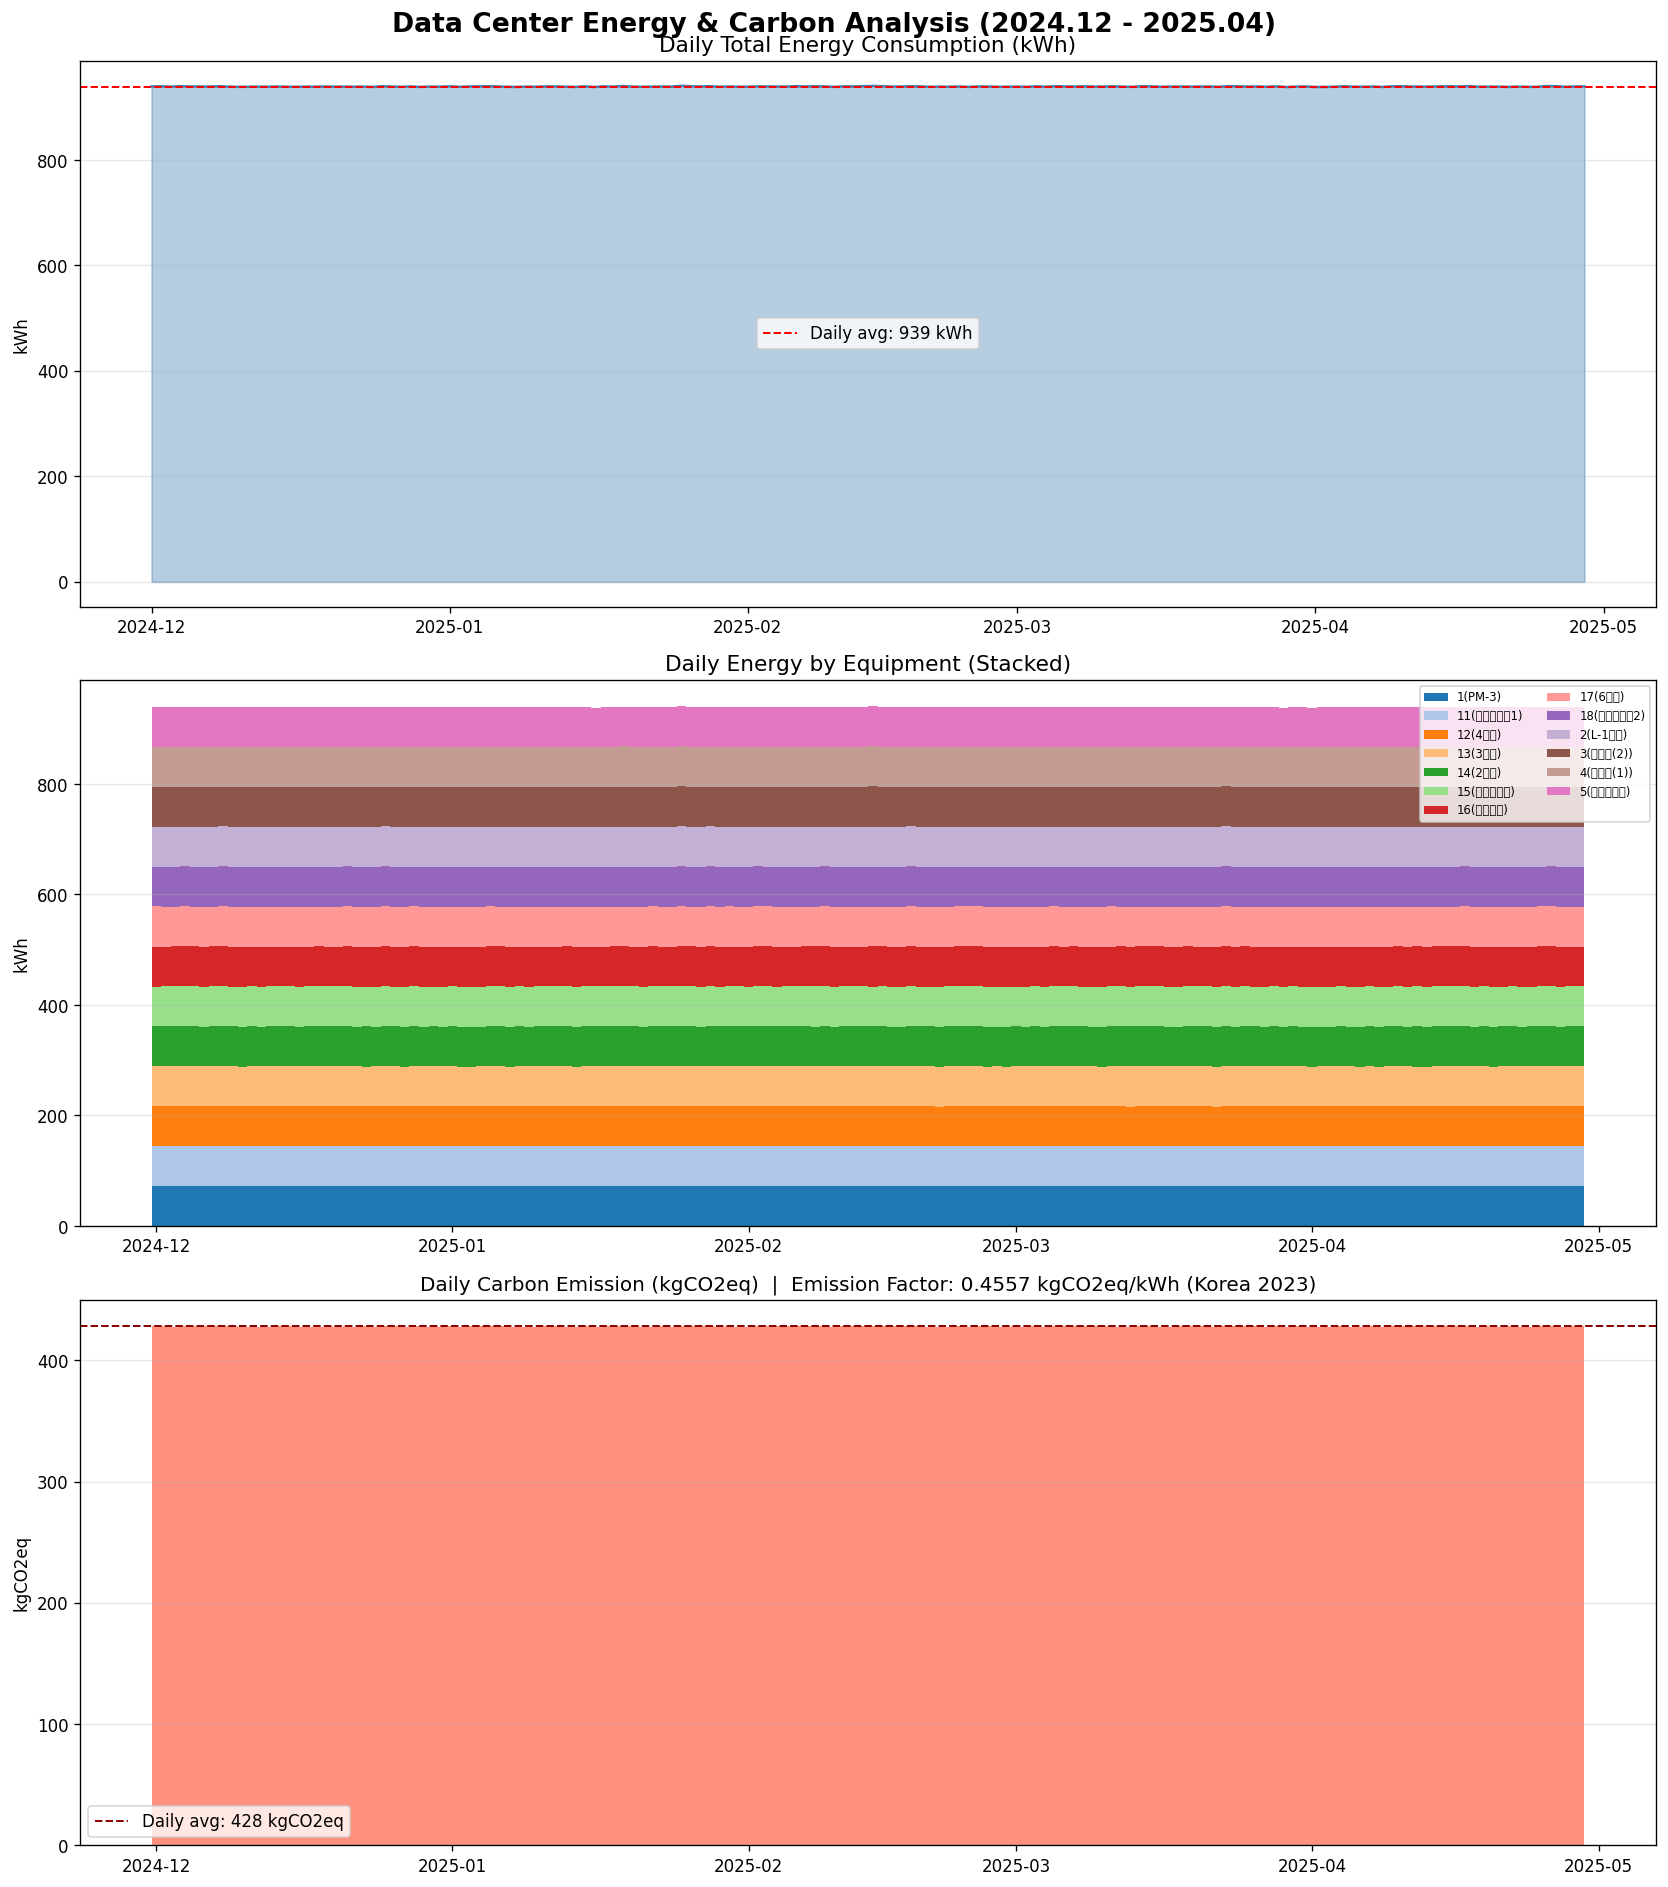

In [10]:
# 마지막 날 데이터 제외 (수집 불완전)
daily_total = daily_total[daily_total['date'] < daily_total['date'].max()]
daily_energy = daily_energy[daily_energy['date'] < daily_energy['date'].max()]
daily_total['date'] = pd.to_datetime(daily_total['date'])
daily_energy['date'] = pd.to_datetime(daily_energy['date'])

fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle('Data Center Energy & Carbon Analysis (2024.12 - 2025.04)',
             fontsize=16, fontweight='bold', y=0.98)

# Chart 1: 일별 에너지 소비량
ax1 = axes[0]
ax1.fill_between(daily_total['date'], daily_total['total_kwh'], alpha=0.4, color='steelblue')
ax1.plot(daily_total['date'], daily_total['total_kwh'], color='steelblue', linewidth=1.5)
ax1.axhline(daily_total['total_kwh'].mean(), color='red', linestyle='--', linewidth=1.2,
            label=f"Daily avg: {daily_total['total_kwh'].mean():,.0f} kWh")
ax1.set_title('Daily Total Energy Consumption (kWh)', fontsize=13)
ax1.set_ylabel('kWh')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.grid(axis='y', alpha=0.3)

# Chart 2: 설비별 누적 에너지 (누적 막대)
ax2 = axes[1]
equip_list = daily_energy['equipment'].unique()
colors = plt.cm.tab20.colors
bottom = None
for i, equip in enumerate(equip_list):
    eq_data = daily_energy[daily_energy['equipment'] == equip].set_index('date')['energy_kwh']
    eq_data = eq_data.reindex(daily_total['date'], fill_value=0)
    if bottom is None:
        ax2.bar(daily_total['date'], eq_data.values, label=equip, color=colors[i % 20], width=1)
        bottom = eq_data.values.copy()
    else:
        ax2.bar(daily_total['date'], eq_data.values, bottom=bottom, label=equip, color=colors[i % 20], width=1)
        bottom += eq_data.values
ax2.set_title('Daily Energy by Equipment (Stacked)', fontsize=13)
ax2.set_ylabel('kWh')
ax2.legend(loc='upper right', fontsize=7, ncol=2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.grid(axis='y', alpha=0.3)

# Chart 3: 일별 탄소 배출량
ax3 = axes[2]
ax3.bar(daily_total['date'], daily_total['co2_kg'], color='tomato', alpha=0.7, width=1)
ax3.axhline(daily_total['co2_kg'].mean(), color='darkred', linestyle='--', linewidth=1.2,
            label=f"Daily avg: {daily_total['co2_kg'].mean():,.0f} kgCO2eq")
ax3.set_title(f'Daily Carbon Emission (kgCO2eq)  |  Emission Factor: {EMISSION_FACTOR} kgCO2eq/kWh (Korea 2023)', fontsize=12)
ax3.set_ylabel('kgCO2eq')
ax3.legend()
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('energy_carbon_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## 결과 요약

| 항목 | 값 |
|------|-----|
| 탐지된 총 이상치 | 53,914건 (0.160%) |
| 예비건조기·6호기 집중도 | **88.6%** |
| 예비건조기 이상치 역률 중앙값 | 70.8% (정상 92.5% 대비 -22%p) |
| 총 에너지 소비 | 140,866 kWh |
| 총 탄소 배출 | 64.19 tCO₂eq |

**기대 효과:** 역률 95% 유지 시 무효전력 손실 30% 절감, 연간 탄소 배출 5~8% 감소 가능